# 15 - Model Efficiency Analysis

Bu notebook **model eğitmez**.

Amaç, tezdeki modelleri yalnızca sınıflandırma performansına göre değil,
**hesaplama/verimlilik maliyeti** açısından da karşılaştırmaktır.

Ölçülenler:
- toplam parametre sayısı
- model ağırlıklarının yaklaşık bellek boyutu
- yerel model klasörü boyutu
- CPU inference süresi
- örnek/saniye
- örnek başına ortalama gecikme

Ana modeller:
- Original FinBERT
- Fine-tuned FinBERT
- BERT
- DistilBERT
- RoBERTa

Benchmark aynı internal test örnekleri üzerinde ve `max_length=128` ile yapılır.


<!-- thesis-review-note -->
## Çalışma Notu

- Amaç: Modelleri performans yaninda parametre, disk boyutu ve CPU inference hizi ile karsilastirir.
- Girdi: Yerel final_model klasorleri ve ic test ornekleri.
- Çıktı ve değerlendirme: Performans/verimlilik dengesi icin tezde kullanilacak tablo ve grafikleri uretir.
- Sıra notu: Notebook numarasi deney akışındaki yerini gösterir; önceki numaralar tamamlanmadan kalıcı sonuç yorumları güncellenmemelidir.
- Sonuç güvenliği: Bu dosyadaki mevcut output hücreleri ve kalıcı sonuç dosyaları korunur.


In [1]:

from thesis_utils import PROJECT_ROOT, paths

from pathlib import Path
import gc
import time
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")

MAX_LENGTH = 128
BENCHMARK_N = 1000
BATCH_SIZE = 32
WARMUP_BATCHES = 2
REPEATS = 3
DEVICE = torch.device("cpu")

TEXT_COL = "input_text"

CHECKPOINT_ROOT = paths.MODEL_CHECKPOINT_ROOT
OUTPUT_DIR = paths.MODEL_RESULTS_ROOT / "model_efficiency"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEST_PATH = paths.PLAIN_SENTIMENT_SPLIT_V1_DIR / "test_df.parquet"

print("Benchmark device:", DEVICE)
print("Output dir      :", OUTPUT_DIR)


Benchmark device: cpu
Output dir      : D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_efficiency


In [2]:

if not TEST_PATH.exists():
    raise FileNotFoundError(f"Internal test split bulunamadı: {TEST_PATH}")

test_df = pd.read_parquet(TEST_PATH)

if TEXT_COL not in test_df.columns:
    raise ValueError(f"Test splitinde {TEXT_COL} kolonu yok.")

benchmark_df = test_df[[TEXT_COL]].dropna().copy().reset_index(drop=True)
benchmark_df[TEXT_COL] = benchmark_df[TEXT_COL].astype(str)
benchmark_df = benchmark_df.iloc[:min(BENCHMARK_N, len(benchmark_df))].copy()

benchmark_texts = benchmark_df[TEXT_COL].tolist()

print("Benchmark N:", len(benchmark_texts))
display(benchmark_df.head(3))


Benchmark N: 1000


,input_text
0,Looking Through The Smoke To Altria’s Future
1,Westlake Chemical stock price target raised to...
2,"QD, HEXO among premarket losers"


In [3]:

def find_existing_dir(candidates):
    for path in candidates:
        path = Path(path)
        if path.exists() and (path / "config.json").exists():
            return path
    return None


bert_local = find_existing_dir([
    CHECKPOINT_ROOT / "bert" / "final_model",
    CHECKPOINT_ROOT / "bert_base_uncased" / "final_model",
    CHECKPOINT_ROOT / "bert-base-uncased" / "final_model",
])

distilbert_local = find_existing_dir([
    CHECKPOINT_ROOT / "distilbert" / "final_model",
    CHECKPOINT_ROOT / "distilbert_base_uncased" / "final_model",
    CHECKPOINT_ROOT / "distilbert-base-uncased" / "final_model",
])

roberta_local = find_existing_dir([
    CHECKPOINT_ROOT / "roberta" / "final_model",
    CHECKPOINT_ROOT / "roberta_base" / "final_model",
    CHECKPOINT_ROOT / "roberta-base" / "final_model",
])

finbert_ft_local = find_existing_dir([
    CHECKPOINT_ROOT / "finbert_target_finetuned_seed42" / "final_model",
])

MODELS = [
    {
        "model": "Original FinBERT",
        "model_ref": "ProsusAI/finbert",
        "local_path": None,
    },
    {
        "model": "Fine-tuned FinBERT",
        "model_ref": str(finbert_ft_local) if finbert_ft_local else "ProsusAI/finbert",
        "local_path": finbert_ft_local,
    },
    {
        "model": "BERT",
        "model_ref": str(bert_local) if bert_local else "bert-base-uncased",
        "local_path": bert_local,
    },
    {
        "model": "DistilBERT",
        "model_ref": str(distilbert_local) if distilbert_local else "distilbert-base-uncased",
        "local_path": distilbert_local,
    },
    {
        "model": "RoBERTa",
        "model_ref": str(roberta_local) if roberta_local else "roberta-base",
        "local_path": roberta_local,
    },
]

model_paths_df = pd.DataFrame([
    {
        "model": m["model"],
        "model_ref": m["model_ref"],
        "local_model_found": m["local_path"] is not None,
        "local_path": str(m["local_path"]) if m["local_path"] else "",
    }
    for m in MODELS
])

display(model_paths_df)


,model,model_ref,local_model_found,local_path
0,Original FinBERT,ProsusAI/finbert,False,
1,Fine-tuned FinBERT,D:\serkan.kaymak\financial_sentiment_thesis\fi...,True,D:\serkan.kaymak\financial_sentiment_thesis\fi...
2,BERT,D:\serkan.kaymak\financial_sentiment_thesis\fi...,True,D:\serkan.kaymak\financial_sentiment_thesis\fi...
3,DistilBERT,D:\serkan.kaymak\financial_sentiment_thesis\fi...,True,D:\serkan.kaymak\financial_sentiment_thesis\fi...
4,RoBERTa,D:\serkan.kaymak\financial_sentiment_thesis\fi...,True,D:\serkan.kaymak\financial_sentiment_thesis\fi...


In [4]:

def count_parameters(model):
    return int(sum(p.numel() for p in model.parameters()))


def parameter_memory_mb(model):
    total_bytes = sum(
        p.numel() * p.element_size()
        for p in model.parameters()
    )
    return total_bytes / (1024 ** 2)


def directory_size_mb(path):
    if path is None:
        return np.nan

    path = Path(path)
    if not path.exists():
        return np.nan

    total = 0
    for f in path.rglob("*"):
        if f.is_file():
            try:
                total += f.stat().st_size
            except OSError:
                pass

    return total / (1024 ** 2)


def make_batches(items, batch_size):
    for start in range(0, len(items), batch_size):
        yield items[start:start + batch_size]


def warmup(model, tokenizer, texts):
    n_warm = min(len(texts), WARMUP_BATCHES * BATCH_SIZE)

    with torch.inference_mode():
        for batch_texts in list(make_batches(texts[:n_warm], BATCH_SIZE))[:WARMUP_BATCHES]:
            encoded = tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
            _ = model(**encoded)


def run_inference_once(model, tokenizer, texts):
    start = time.perf_counter()

    with torch.inference_mode():
        for batch_texts in make_batches(texts, BATCH_SIZE):
            encoded = tokenizer(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
            _ = model(**encoded)

    return time.perf_counter() - start


def benchmark_model(model, tokenizer, texts):
    model.to(DEVICE)
    model.eval()

    warmup(model, tokenizer, texts)

    times = []

    for i in range(REPEATS):
        elapsed = run_inference_once(model, tokenizer, texts)
        times.append(elapsed)
        print(f"  repeat {i+1}/{REPEATS}: {elapsed:.3f}s")

    times = np.asarray(times, dtype=float)
    mean_seconds = float(times.mean())
    std_seconds = float(times.std(ddof=1)) if len(times) > 1 else 0.0

    return {
        "n_benchmark": len(texts),
        "batch_size": BATCH_SIZE,
        "repeats": REPEATS,
        "inference_seconds_mean": mean_seconds,
        "inference_seconds_std": std_seconds,
        "samples_per_second": len(texts) / mean_seconds,
        "latency_ms_per_sample": (mean_seconds / len(texts)) * 1000,
    }


In [5]:

results = []

for cfg in MODELS:
    print("\n" + "#" * 90)
    print(cfg["model"])
    print("#" * 90)
    print("Loading:", cfg["model_ref"])

    tokenizer = AutoTokenizer.from_pretrained(cfg["model_ref"], use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(cfg["model_ref"])

    params = count_parameters(model)

    bench = benchmark_model(
        model,
        tokenizer,
        benchmark_texts,
    )

    row = {
        "model": cfg["model"],
        "model_ref": cfg["model_ref"],
        "local_model_found": cfg["local_path"] is not None,
        "parameter_count": params,
        "parameter_memory_mb": parameter_memory_mb(model),
        "local_directory_size_mb": directory_size_mb(cfg["local_path"]),
        **bench,
    }

    results.append(row)

    pd.DataFrame(results).to_csv(
        OUTPUT_DIR / "model_efficiency_results_partial.csv",
        index=False,
        encoding="utf-8-sig",
    )

    del model, tokenizer
    gc.collect()

efficiency_df = pd.DataFrame(results)

display(
    efficiency_df[
        [
            "model",
            "parameter_count",
            "parameter_memory_mb",
            "local_directory_size_mb",
            "inference_seconds_mean",
            "inference_seconds_std",
            "samples_per_second",
            "latency_ms_per_sample",
        ]
    ].round(4)
)



##########################################################################################
Original FinBERT
##########################################################################################
Loading: ProsusAI/finbert


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  repeat 1/3: 31.360s
  repeat 2/3: 31.885s
  repeat 3/3: 34.126s

##########################################################################################
Fine-tuned FinBERT
##########################################################################################
Loading: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\finbert_target_finetuned_seed42\final_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  repeat 1/3: 32.454s
  repeat 2/3: 34.959s
  repeat 3/3: 36.624s

##########################################################################################
BERT
##########################################################################################
Loading: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\bert_base_uncased\final_model


...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  repeat 1/3: 14.537s
  repeat 2/3: 14.162s
  repeat 3/3: 13.978s

##########################################################################################
RoBERTa
##########################################################################################
Loading: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\roberta_base\final_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  repeat 1/3: 28.199s
  repeat 2/3: 27.484s
  repeat 3/3: 27.860s


,model,parameter_count,parameter_memory_mb,local_directory_size_mb,inference_seconds_mean,inference_seconds_std,samples_per_second,latency_ms_per_sample
0,Original FinBERT,109484547,417.6504,NaN,32.4569,1.4687,30.8101,32.4569
1,Fine-tuned FinBERT,109484547,417.6504,418.3580,34.6789,2.0992,28.8360,34.6789
2,BERT,109484547,417.6504,418.3580,31.8760,3.9692,31.3716,31.8760
3,DistilBERT,66955779,255.4160,256.1130,14.2258,0.2849,70.2950,14.2258
4,RoBERTa,124647939,475.4942,478.9176,27.8477,0.3579,35.9096,27.8477


In [6]:

if "BERT" in set(efficiency_df["model"]):
    bert = efficiency_df[efficiency_df["model"] == "BERT"].iloc[0]

    efficiency_df["speed_vs_bert"] = (
        efficiency_df["samples_per_second"]
        / float(bert["samples_per_second"])
    )

    efficiency_df["params_vs_bert"] = (
        efficiency_df["parameter_count"]
        / float(bert["parameter_count"])
    )
else:
    efficiency_df["speed_vs_bert"] = np.nan
    efficiency_df["params_vs_bert"] = np.nan

final_path = OUTPUT_DIR / "model_efficiency_results.csv"
efficiency_df.to_csv(final_path, index=False, encoding="utf-8-sig")

display(
    efficiency_df[
        [
            "model",
            "parameter_count",
            "samples_per_second",
            "latency_ms_per_sample",
            "speed_vs_bert",
            "params_vs_bert",
        ]
    ].round(4)
)

print("Saved:", final_path)


,model,parameter_count,samples_per_second,latency_ms_per_sample,speed_vs_bert,params_vs_bert
0,Original FinBERT,109484547,30.8101,32.4569,0.9821,1.0000
1,Fine-tuned FinBERT,109484547,28.8360,34.6789,0.9192,1.0000
2,BERT,109484547,31.3716,31.8760,1.0000,1.0000
3,DistilBERT,66955779,70.2950,14.2258,2.2407,0.6116
4,RoBERTa,124647939,35.9096,27.8477,1.1447,1.1385


Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_efficiency\model_efficiency_results.csv


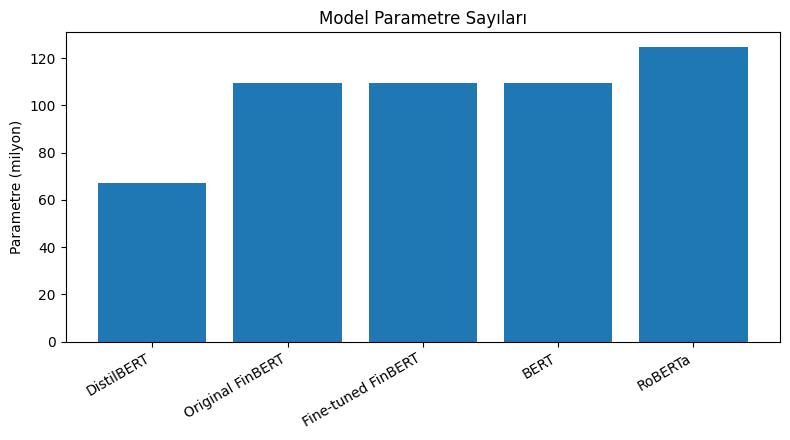

Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_efficiency\model_parameter_count.png


In [7]:

plot_df = efficiency_df.sort_values("parameter_count").copy()

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(plot_df))
values = plot_df["parameter_count"].to_numpy() / 1_000_000

ax.bar(x, values)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=30, ha="right")
ax.set_ylabel("Parametre (milyon)")
ax.set_title("Model Parametre Sayıları")

fig.tight_layout()

path = OUTPUT_DIR / "model_parameter_count.png"
fig.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


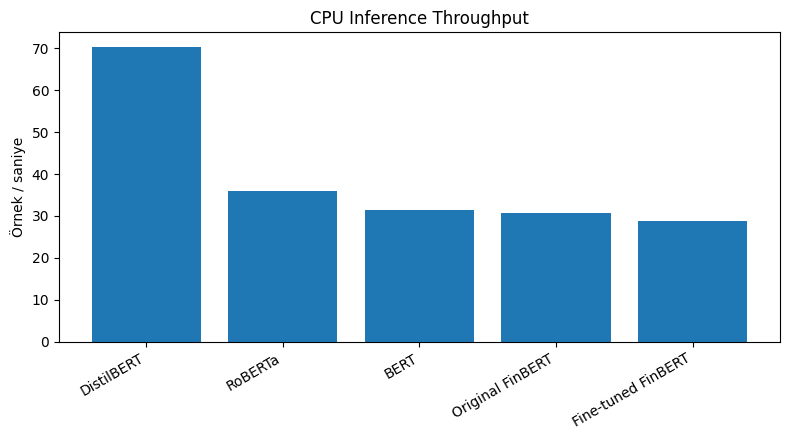

Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_efficiency\cpu_inference_samples_per_second.png


In [8]:

plot_df = efficiency_df.sort_values("samples_per_second", ascending=False).copy()

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(plot_df))
values = plot_df["samples_per_second"].to_numpy()

ax.bar(x, values)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=30, ha="right")
ax.set_ylabel("Örnek / saniye")
ax.set_title("CPU Inference Throughput")

fig.tight_layout()

path = OUTPUT_DIR / "cpu_inference_samples_per_second.png"
fig.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


In [9]:

internal_macro_f1 = {
    "Original FinBERT": 0.6794,
    "BERT": 0.8378,
    "DistilBERT": 0.8218,
    "RoBERTa": 0.8651,
}

finbert_summary_path = (
    paths.MODEL_RESULTS_ROOT
    / "finbert_target_finetuned_seed42"
    / "training_evaluation"
    / "finbert_target_finetune_summary.csv"
)

if finbert_summary_path.exists():
    temp = pd.read_csv(finbert_summary_path)
    if len(temp) == 1 and "test_f1_macro" in temp.columns:
        internal_macro_f1["Fine-tuned FinBERT"] = float(
            temp.iloc[0]["test_f1_macro"]
        )

efficiency_df["internal_macro_f1"] = efficiency_df["model"].map(internal_macro_f1)

tradeoff_df = efficiency_df[
    [
        "model",
        "internal_macro_f1",
        "parameter_count",
        "samples_per_second",
        "latency_ms_per_sample",
        "speed_vs_bert",
        "params_vs_bert",
    ]
].copy()

tradeoff_path = OUTPUT_DIR / "performance_efficiency_tradeoff.csv"
tradeoff_df.to_csv(tradeoff_path, index=False, encoding="utf-8-sig")

display(tradeoff_df.round(4))
print("Saved:", tradeoff_path)


,model,internal_macro_f1,parameter_count,samples_per_second,latency_ms_per_sample,speed_vs_bert,params_vs_bert
0,Original FinBERT,0.6794,109484547,30.8101,32.4569,0.9821,1.0000
1,Fine-tuned FinBERT,0.8512,109484547,28.8360,34.6789,0.9192,1.0000
2,BERT,0.8378,109484547,31.3716,31.8760,1.0000,1.0000
3,DistilBERT,0.8218,66955779,70.2950,14.2258,2.2407,0.6116
4,RoBERTa,0.8651,124647939,35.9096,27.8477,1.1447,1.1385


Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_efficiency\performance_efficiency_tradeoff.csv


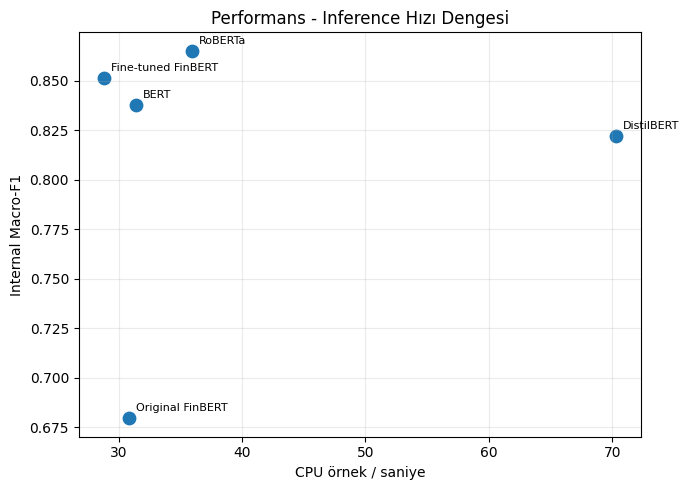

Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_efficiency\performance_vs_inference_speed.png


In [10]:

scatter_df = efficiency_df.dropna(
    subset=["internal_macro_f1", "samples_per_second"]
).copy()

if len(scatter_df):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(
        scatter_df["samples_per_second"],
        scatter_df["internal_macro_f1"],
        s=80,
    )

    for row in scatter_df.itertuples(index=False):
        ax.annotate(
            row.model,
            (row.samples_per_second, row.internal_macro_f1),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    ax.set_xlabel("CPU örnek / saniye")
    ax.set_ylabel("Internal Macro-F1")
    ax.set_title("Performans - Inference Hızı Dengesi")
    ax.grid(alpha=0.25)

    fig.tight_layout()

    path = OUTPUT_DIR / "performance_vs_inference_speed.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", path)


In [11]:

fastest = efficiency_df.sort_values(
    "samples_per_second",
    ascending=False
).iloc[0]

smallest = efficiency_df.sort_values(
    "parameter_count"
).iloc[0]

summary_lines = [
    f"En hızlı CPU inference modeli: {fastest['model']} "
    f"({fastest['samples_per_second']:.2f} örnek/s).",
    f"En az parametreli model: {smallest['model']} "
    f"({smallest['parameter_count'] / 1_000_000:.2f} milyon parametre).",
]

if "DistilBERT" in set(efficiency_df["model"]):
    d = efficiency_df[efficiency_df["model"] == "DistilBERT"].iloc[0]
    summary_lines.append(
        f"DistilBERT'in BERT'e göre throughput oranı: "
        f"{d['speed_vs_bert']:.2f}x; parametre oranı: "
        f"{d['params_vs_bert']:.2f}x."
    )

summary_text = "\n".join(summary_lines)

summary_path = OUTPUT_DIR / "efficiency_findings_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("Saved:", summary_path)


En hızlı CPU inference modeli: DistilBERT (70.30 örnek/s).
En az parametreli model: DistilBERT (66.96 milyon parametre).
DistilBERT'in BERT'e göre throughput oranı: 2.24x; parametre oranı: 0.61x.
Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\model_efficiency\efficiency_findings_summary.txt


## Bana göndermen gerekenler

Notebook tamamlandığında:

- `model_efficiency/model_efficiency_results.csv`
- `model_efficiency/performance_efficiency_tradeoff.csv`

dosyalarını gönder.

Grafikler:
- `model_parameter_count.png`
- `cpu_inference_samples_per_second.png`
- `performance_vs_inference_speed.png`

**Önemli kontrol:** İlk path tablosunda BERT, DistilBERT, RoBERTa veya Fine-tuned FinBERT için
`local_model_found=False` görünürse bana o modelin gerçek `final_model` klasör yolunu gönder.
Base checkpoint'i yanlışlıkla fine-tuned model gibi raporlamayalım.
